# Sentiment Analysis IMBD Dataset Advance #

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from src.preprocessing import TextCleaner
import shap
import numpy as np
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\renus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\renus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Loading data ##

In [25]:
df = pd.read_csv("IMDB Dataset.csv")
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

## Spliting the raw data ##

In [28]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["review"], df["label"], test_size=0.2, random_state=42)

## Defining pipeline ##

In [31]:
pipeline = Pipeline([
    ("cleaner", TextCleaner()),
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=200))])

## Training Model ##

In [34]:
pipeline.fit(X_train_raw, y_train)

Pipeline(steps=[('cleaner', TextCleaner()),
                ('tfidf', TfidfVectorizer(max_features=5000)),
                ('clf', LogisticRegression(max_iter=200))])

## Model Candidates ##

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

## Evaluating Each Model ##

In [40]:
best_model = None
best_score = 0
best_pipeline = None

for name, model in models.items():
    pipeline = Pipeline([
        ('cleaner', TextCleaner()),
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', model)
    ])
    pipeline.fit(X_train_raw, y_train)
    y_pred = pipeline.predict(X_test_raw)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    if acc > best_score:
        best_score = acc
        best_model = model
        best_pipeline = pipeline


Logistic Regression
Accuracy: 0.8893
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Random Forest
Accuracy: 0.8514
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


SVM
Accuracy: 0.8818
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88   

C:\Users\renus\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:46:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.8591
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4961
           1       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



## Predicting and Evaluating ##

In [42]:
y_pred = pipeline.predict(X_test_raw)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8591
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4961
           1       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



## SHAP Explainability for best model ##


Generating SHAP explanations for best model...


C:\Users\renus\AppData\Local\Temp\ipykernel_28068\1707777446.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_vec[:20], feature_names=tfidf.get_feature_names_out(), show=False)


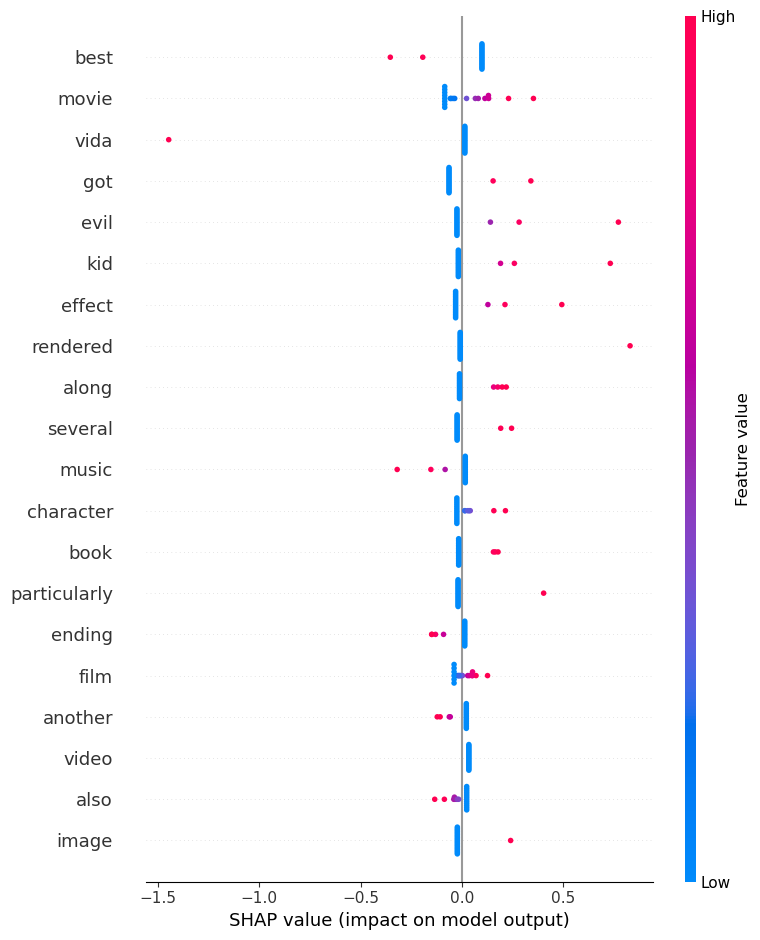

In [48]:
# SHAP Explainability for best model (must be tree-based or linear)
print("\nGenerating SHAP explanations for best model...")

# Prepare cleaned and vectorized data
sample_X = X_train_raw[:200]
cleaned_sample = TextCleaner().fit_transform(sample_X)
tfidf = TfidfVectorizer(max_features=5000)
X_vec = tfidf.fit_transform(cleaned_sample).toarray()  # Convert to dense

# Select explainer
if isinstance(best_model, (RandomForestClassifier, XGBClassifier)):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, LogisticRegression):
    explainer = shap.Explainer(best_model, X_vec)
else:
    explainer = shap.Explainer(best_model, X_vec)

# Generate SHAP values
shap_values = explainer(X_vec[:20])
shap.summary_plot(shap_values, X_vec[:20], feature_names=tfidf.get_feature_names_out(), show=False)
plt.tight_layout()
plt.show()



## Creating Pickle files ##

In [51]:
import joblib
import os

# Create the models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Extract trained model and vectorizer from pipeline
model = best_pipeline.named_steps['clf']
tfidf = best_pipeline.named_steps['tfidf']

# Save both to .pkl files
joblib.dump(model, 'models/best_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

print("✅ Model and TF-IDF vectorizer saved successfully.")


✅ Model and TF-IDF vectorizer saved successfully.
